In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import joblib
import json

### Read Images

In [16]:
I1 = cv2.imread("E:/Documents/6th Semester/DIP/Lab/Assignment#002/wbc_data/Test/Basophil/Basophil_1.jpg", 0)
I2 = cv2.imread("E:/Documents/6th Semester/DIP/Lab/Assignment#002/wbc_data/Test/Eosinophil/Eosinophil_2.jpg",0)
I3= cv2.imread("E:/Documents/6th Semester/DIP/Lab/Assignment#002/wbc_data/Test/Lymphocyte/Lymphocyte_2.jpg",0)
I4= cv2.imread("E:/Documents/6th Semester/DIP/Lab/Assignment#002/wbc_data/Test/Monocyte/Monocyte_2.jpg",0)
I5= cv2.imread("E:/Documents/6th Semester/DIP/Lab/Assignment#002/wbc_data/Test/Neutrophil/Neutrophil_2.jpg",0)
x, y = I1.shape

### Butterworth High Pass Filter

In [6]:
def butterworth_high_pass(D0, n, rows, cols):
    u = np.arange(rows)
    v = np.arange(cols)
    U, V = np.meshgrid(u - rows//2, v - cols//2, indexing='ij')
    D = np.sqrt(U**2 + V**2)
    H = 1 / (1 + (D0 / (D + 1e-5))**(2 * n))  # Add small value to avoid div by zero
    return H

### Histogram Equalization

In [7]:
def Equalization(I1):
    hist, bins = np.histogram(I1.flatten(), 256, [0,256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max()
    cdf = (255 * cdf / cdf[-1]).astype(np.uint8)
    return cdf[I1]


### Image Clustering

In [8]:
def global_threshold(image, thresh=128):
    _, binary = cv2.threshold(image, thresh, 255, cv2.THRESH_BINARY)
    return binary

### Connected Component Analysis 8

In [9]:
def CCA_8(img,I1):
    x,y=I1.shape
    label = 1
    a=np.zeros((x,y),dtype=np.uint16)
    equivalences = {}  
    I2=copy.deepcopy(img)

    for i in range(x):
        for j in range(y):
            pixel_value=I1[i,j]
        
            if pixel_value <128:
                neighbors = []
                
                if j > 0 and a[i, j - 1] > 0:               #if left neighbor belong to vset
                    neighbors.append(a[i, j - 1])

                if i > 0 and a[i - 1, j] > 0:                #if top neighbor belong to vset
                    neighbors.append(a[i - 1, j])
 
                if i > 0 and j>0 and a[i - 1, j-1] > 0:                #if left upper diagonal neighbor belong to vset
                    neighbors.append(a[i - 1, j-1])
                
                if (j!=(y-1)):

                    if i > 0 and a[i - 1, j+1] > 0:                #if left upper diagonal neighbor belong to vset
                        neighbors.append(a[i - 1, j+1])               

                
                if not neighbors:                               #if no neighbor belong to vset
                    a[i, j] = label
                    equivalences[label] = {label}  
                    label += 1
                else:
                    min_label = min(neighbors)                  #asigns minimum label from neighbors
                    a[i, j] = min_label
                    
                    for k in neighbors:
                        equivalences[k] = equivalences[min_label] #updates equivalence list for each neighbour to minimum label 

    for i in range(x):
        for j in range(y):
            if a[i, j] > 0:
                a[i, j] = min(equivalences[a[i, j]]) 

    nucleus_label= a[int(x/2),int(y/2)]

    
    if I1[int(x/2),int(x/2)]== 255:
        check=False
        for i in range (int(x/2),x):
            for j in range (int(y/2),y):
                nucleus_label= a[i,j]
                if I1[i,j]!= 255:
                    check=True
                    break
            if (check==True):
                break
                
    for i in range(x):
        for j in range(y):
            if a[i, j] != nucleus_label:
                I2[i,j] = 255

    return I2

         

### Nucleus Extraction

In [10]:
def extract_nucleus(I1):
    F = np.fft.fft2(I1)
    F_shifted = np.fft.fftshift(F)
    
    x, y = I1.shape
    D0 = 15  
    n = 1     
    BHPF = butterworth_high_pass(D0, n, x, y)

    F_filtered = F_shifted * BHPF

    F_ishifted = np.fft.ifftshift(F_filtered)
    img_sharpened = np.fft.ifft2(F_ishifted)
    img_sharpened = np.abs(img_sharpened)
    img_sharpened = np.uint8(np.clip(img_sharpened, 0, 255))
    img_sharpened=Equalization(img_sharpened+I1)
    img_thershold=global_threshold(img_sharpened,128)


    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3,3))
    img_closed= cv2.morphologyEx(img_thershold, cv2.MORPH_CLOSE, kernel)

    img_CCA8=CCA_8(I1,img_closed)
    return img_CCA8


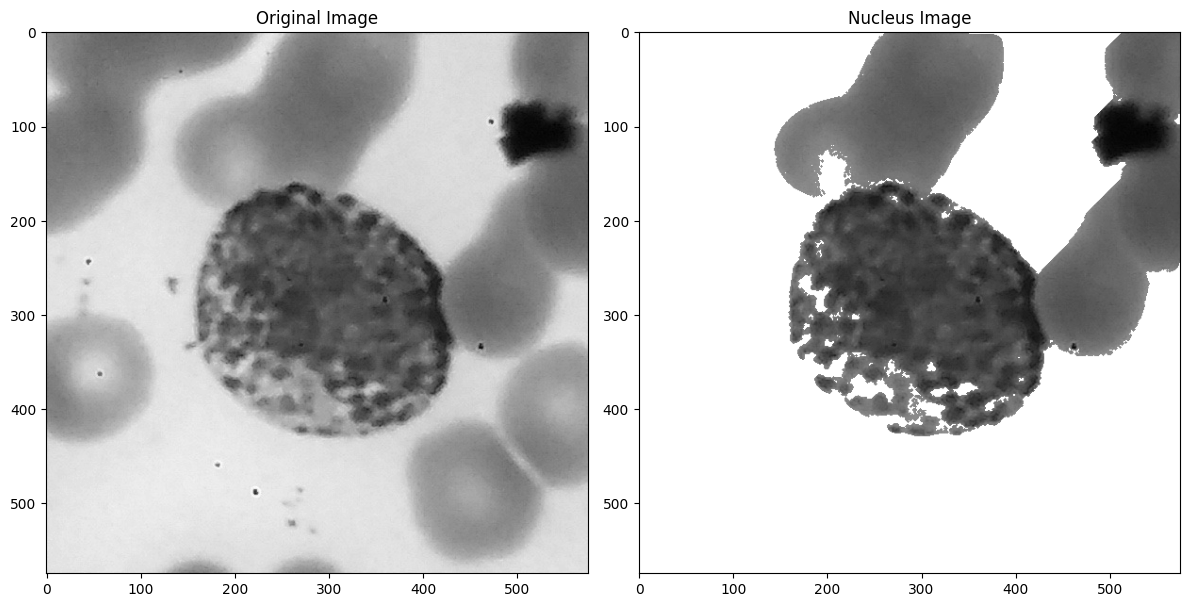

In [17]:
I1_nucleus=extract_nucleus(I1)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(I1, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Nucleus Image")
plt.imshow(I1_nucleus, cmap='gray')

plt.tight_layout()
plt.show()

### Local Binary Pattern

In [92]:
def conv_binary(vector):
    value = 0
    for i in range(8):
        value += vector[7 - i] * (2 ** i)
    return int(value)

def local_binary_pattern(I1):
    x, y = I1.shape
    output = np.zeros((x, y), dtype=np.uint8)
    padded_image = np.pad(I1, ((1, 1), (1, 1)), mode='constant', constant_values=0)

    for i in range(1, x + 1):
        for j in range(1, y + 1):
            center = padded_image[i, j]

            if center == 255:
                output[i - 1, j - 1] = 0  
                continue

            region = padded_image[i - 1:i + 2, j - 1:j + 2]
            vec = np.zeros(8, dtype=np.uint8)

            neighbors = [
                region[0, 0], region[0, 1], region[0, 2],  
                region[1, 2],                              
                region[2, 2], region[2, 1], region[2, 0],  
                region[1, 0]                               
            ]

            for k in range(8):
                vec[k] = 1 if neighbors[k] >= center else 0

            output[i - 1, j - 1] = conv_binary(vec)

    return output

### Hough Transformation

In [ ]:
def extract_hog(image, cell_size=8, block_size=2, bins=9):
    gx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=3)

    magnitude = np.sqrt(gx**2 + gy**2)
    angle = np.arctan2(gy, gx) * (180 / np.pi) % 180  # [0, 180)

    h, w = image.shape
    n_cells_x = w // cell_size
    n_cells_y = h // cell_size
    bin_width = 180 // bins

    hog = np.zeros((n_cells_y, n_cells_x, bins), dtype=np.float32)

    for i in range(n_cells_y):
        for j in range(n_cells_x):
            cell_mag = magnitude[i*cell_size:(i+1)*cell_size, j*cell_size:(j+1)*cell_size]
            cell_angle = angle[i*cell_size:(i+1)*cell_size, j*cell_size:(j+1)*cell_size]

            hist = np.zeros(bins)
            for x in range(cell_size):
                for y in range(cell_size):
                    bin_idx = int(cell_angle[x, y] // bin_width) % bins
                    hist[bin_idx] += cell_mag[x, y]

            hog[i, j] = hist

    
    hog_vector = []
    for i in range(n_cells_y - block_size + 1):
        for j in range(n_cells_x - block_size + 1):
            block = hog[i:i+block_size, j:j+block_size].flatten()
            norm = np.linalg.norm(block) + 1e-6  
            block = block / norm
            hog_vector.extend(block)

    return np.array(hog_vector)


### Extracting Nucleus Features

In [94]:
def extract_shape_features(nucleus_img):
    # Convert to binary if needed
    _, binary = cv2.threshold(nucleus_img, 254, 255, cv2.THRESH_BINARY_INV)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None  # No contour found

    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)
    circularity = 4 * np.pi * area / (perimeter**2 + 1e-5)
    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = float(w) / h

    M = cv2.moments(cnt)
    cx = M['m10'] / (M['m00'] + 1e-5)
    cy = M['m01'] / (M['m00'] + 1e-5)

    features = {
        "area": area,
        "perimeter": perimeter,
        "circularity": circularity,
        "aspect_ratio": aspect_ratio,
        "centroid_x": cx,
        "centroid_y": cy
    }

    if features:
        full_feature_vector = [
            features["area"],
            features["perimeter"],
            features["circularity"],
            features["aspect_ratio"],
            features["centroid_x"],
            features["centroid_y"],
        ]

        return full_feature_vector


### Extract all Features

In [95]:
def extract_all_features(img):
    nucleus = extract_nucleus(img)
    feats = extract_shape_features(nucleus)
    img = cv2.resize(img, (128, 128))  

    lbp_feat = local_binary_pattern(img)
    lbp_feat = lbp_feat.flatten()
    hog_feat = extract_hog(img)

    combined = np.hstack((lbp_feat, hog_feat,feats))
    return combined

### Buliding the Dataset

In [ ]:
def build_dataset(path):
    X = []
    y = []
    label_map = {}
    label_idx = 0

    for folder in os.listdir(path):
        folder_path = os.path.join(path, folder)
        if not os.path.isdir(folder_path): continue

        if folder not in label_map:
            label_map[folder] = label_idx
            label_idx += 1

        for file in os.listdir(folder_path):
            if file.lower().endswith(('.png', '.jpg', '.tif')):
                img = cv2.imread(os.path.join(folder_path, file), 0)
                combined=extract_all_features(img)
                X.append(combined)
                y.append(label_map[folder])

    return np.array(X), np.array(y), label_map


### Training the Model

Accuracy: 0.55
              precision    recall  f1-score   support

    Basophil       0.96      0.86      0.91        28
  Eosinophil       0.27      0.57      0.36        14
  Lymphocyte       0.50      0.90      0.64        10
    Monocyte       0.36      0.21      0.26        24
  Neutrophil       0.69      0.38      0.49        24

    accuracy                           0.55       100
   macro avg       0.56      0.58      0.53       100
weighted avg       0.61      0.55      0.55       100



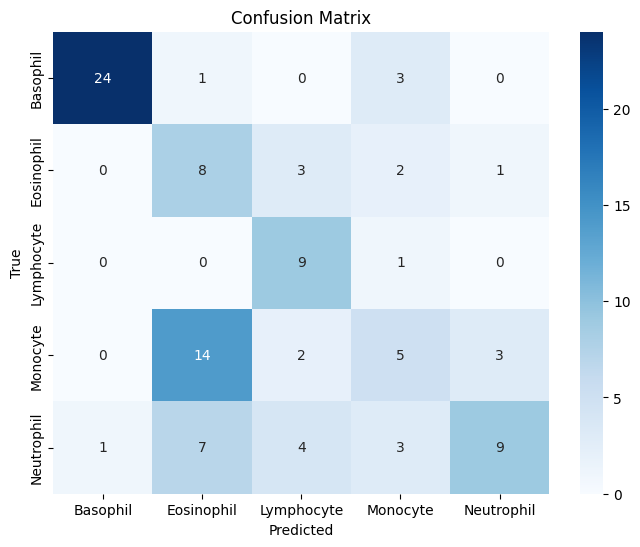

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

X, y, label_map = build_dataset("E:/Documents/6th Semester/DIP/Lab/Assignment#002/wbc_data/Train")

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred, target_names=label_map.keys()))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_map.keys(), yticklabels=label_map.keys(), cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


### Save the Model

In [98]:
joblib.dump(model, 'wbc_classifier_model.pkl')
joblib.dump(scaler, 'wbc_scaler.pkl')
with open('wbc_label_map.json', 'w') as f:
    json.dump(label_map, f)

### Load the Model

In [99]:
model = joblib.load('wbc_classifier_model.pkl')
scaler = joblib.load('wbc_scaler.pkl')

with open('wbc_label_map.json', 'r') as f:
    label_map = json.load(f)

inv_label_map = {v: k for k, v in label_map.items()}

### Test the Images


✅ Accuracy on Test Set: 0.66

🔍 Classification Report:

              precision    recall  f1-score   support

    Basophil       0.96      0.94      0.95        50
  Eosinophil       0.45      0.68      0.54        50
  Lymphocyte       0.89      0.94      0.91        50
    Monocyte       0.50      0.32      0.39        50
  Neutrophil       0.55      0.44      0.49        50

    accuracy                           0.66       250
   macro avg       0.67      0.66      0.66       250
weighted avg       0.67      0.66      0.66       250

📊 Confusion Matrix:



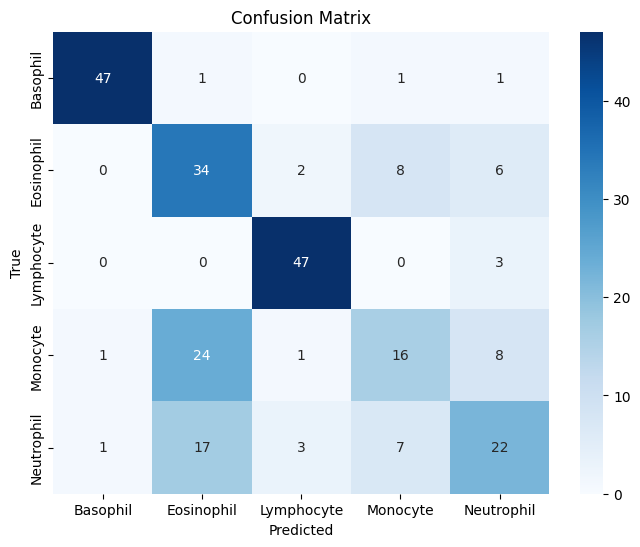

In [100]:
# --- Evaluate Test Set ---
X_test = []
y_test = []

test_path = "E:/Documents/6th Semester/DIP/Lab/Assignment#002/wbc_data/Test"

for folder in os.listdir(test_path):
    folder_path = os.path.join(test_path, folder)
    if not os.path.isdir(folder_path): continue
    
    true_label = label_map[folder]
    
    for file in os.listdir(folder_path):
        if file.lower().endswith(('.jpg', '.png', '.tif')):
            img = cv2.imread(os.path.join(folder_path, file), 0)
            features = extract_all_features(img)
            if features is not None:
                X_test.append(features)
                y_test.append(true_label)

X_test = np.array(X_test)
y_test = np.array(y_test)

# Normalize
X_test_scaled = scaler.transform(X_test)

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy on Test Set: {acc:.2f}\n")
print("🔍 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_map.keys()))
print("📊 Confusion Matrix:\n")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_map.keys(), yticklabels=label_map.keys(), cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

